In [9]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pk
from IPython.display import Image, display
import os
import sys
from sklearn import decomposition



In [2]:
main_dir = os.getcwd()
if "notebooks" in main_dir:
    main_dir = main_dir[:-10]
elif main_dir == "/content":
    main_dir = main_dir + "/GPA-source_code"
os.chdir(main_dir)
print(main_dir)

contrast_colors = {
    1: '#1f77b4',  # blue
    2: '#2ca02c',  # green
    3: '#ff7f0e',  # orange
    4: '#8c564b',  # brown
    5: '#d62728',  # red 
    6: '#9467bd'  # purple (to be used for index 8)
}

data_dir = main_dir + '/data/'

/Users/yuchench/Desktop/source_code_threshold_v1_updated


In [3]:

#loads weights, biases and parameters of trained velocity field
def load_W(filename):
    with open(filename, "rb") as fr:
        W, b, p = pk.load(fr)

    W = [tf.Variable(w,  dtype=tf.float32) for w in W]
    b = [tf.Variable(b_,  dtype=tf.float32) for b_ in b]

    return W, b, p

    
def v(x, t, W, b):   # neural newtork for time-dependent vectorfield
    num_layers = len(W)
    activation_ftn = tf.nn.tanh
        
    h = tf.concat([x, t*tf.ones([x.shape[0], 1], dtype=tf.float32)], axis=1)
    for l in range(0,num_layers-1):
        h = activation_ftn(tf.add(tf.matmul(h, W[l]), b[l]))
    out=tf.add(tf.matmul(h, W[-1]), b[-1])

    return out

#returns a list of positions over time
def time_integration(x0, T, dt):
    x = tf.constant(x0, dtype=tf.float32)
    xs = [x0]
    for i in range(int(T/dt)):
        vv = v(x, dt*i, W, b)
        x += dt * vv
        xs.append(x.numpy())
    return xs



In [4]:

from scripts.util.visualizations import generate_W2distance_plot
from scripts.util.visualizations import generate_static_trajectory_plots_three_timepoints
from scripts.util.visualizations import generate_static_trajectory_plots_two_timepoints
from scripts.util.visualizations import generate_static_trajectory_plots_two_timepoints_no_middle
from scripts.util.visualizations import generate_static_cluster_plot_target
from scripts.util.visualizations import generate_static_cluster_plot_source
from scripts.util.visualizations import classify_X1_hat
from scripts.util.visualizations import classify_X2_hat


## Import Preprocessed Data and Define Dimensionality Reduction

- Please ensure you have run the `Preprocess_datasets.ipynb` notebook for the dataset you intend to use for downstream analysis.
- The preprocessed data should be saved in the `data/` folder with filenames ending in `_preprocessed.pkl`.
- When loading the preprocessed data below, make sure to use the correct and compatible filename corresponding to your dataset.
- Each of the following cells corresponds to a specific dataset. **Only run the cell for the dataset you're working with** to avoid overwriting previously loaded data.


In [7]:
## Loads preprocessed synthetic data

data_name = "synthetic"

#loads the original data matrices
preprocessed_filename = data_dir + data_name + "_preprocessed.pkl"
with open(preprocessed_filename, "rb") as fr:
    try:
        time_label, full_matrix, projected_matrix, pca = pk.load(fr)
    except:
        time_label, full_matrix = pk.load(fr)   

pca = decomposition.PCA(n_components=26, random_state=0)
pca.fit(full_matrix)

d_red = 26
dimension_reduction = True

cls = set(time_label)
mats = {}
for c in cls:
    mats[c] = full_matrix[time_label == c].astype(float)




In [6]:
## Loads preprocessed mESC data

data_name = "mESC"

#loads the original data matrices
preprocessed_filename = data_dir + data_name + "_preprocessed.pkl"
with open(preprocessed_filename, "rb") as fr:
    try:
        time_label, full_matrix, projected_matrix, pca = pk.load(fr)
    except:
        time_label, full_matrix = pk.load(fr)   

pca = decomposition.PCA(n_components=2, random_state=0)
pca.fit(full_matrix)

d_red = 2
dimension_reduction = True

cls = set(time_label)
mats = {}
for c in cls:
    mats[c] = full_matrix[time_label == c].astype(float)





/Users/yuchench/miniforge3/envs/gpa/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.2.1 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
## Loads preprocessed EMT data

data_name = "emt_72"

#loads the original data matrices
preprocessed_filename = data_dir + data_name + "_preprocessed.pkl"
with open(preprocessed_filename, "rb") as fr:
    try:
        time_label, full_matrix, projected_matrix, pca = pk.load(fr)
    except:
        time_label, full_matrix = pk.load(fr)   

pca = decomposition.PCA(n_components=8, random_state=0)
pca.fit(full_matrix)

d_red = 8
dimension_reduction = True

cls = set(time_label)
mats = {}
for c in cls:
    mats[c] = full_matrix[time_label == c].astype(float)



In [12]:
## Loads preprocessed MCF7 cell line data

data_name = "MCF7"

#loads the original data matrices
preprocessed_filename = data_dir + data_name + "_preprocessed.pkl"
with open(preprocessed_filename, "rb") as fr:
    try:
        time_label, full_matrix, projected_matrix, pca = pk.load(fr)
    except:
        time_label, full_matrix = pk.load(fr)   

pca = decomposition.PCA(n_components=2, random_state=0)
pca.fit(full_matrix)

d_red = 2
dimension_reduction = True

cls = set(time_label)
mats = {}
for c in cls:
    mats[c] = full_matrix[time_label == c].astype(float)


In [17]:
## Loads preprocessed MCF7 cell line data

data_name = "PA3"

#loads the original data matrices
preprocessed_filename = data_dir + data_name + "_preprocessed.pkl"
with open(preprocessed_filename, "rb") as fr:
    try:
        time_label, full_matrix, projected_matrix, pca = pk.load(fr)
    except:
        time_label, full_matrix = pk.load(fr)   

pca = decomposition.PCA(n_components=2, random_state=0)
pca.fit(full_matrix)

d_red = 2
dimension_reduction = True

cls = set(time_label)
mats = {}
for c in cls:
    mats[c] = full_matrix[time_label == c].astype(float)


In [5]:
## Loads preprocessed MCF7 cell line data

data_name = "862"

#loads the original data matrices
preprocessed_filename = data_dir + data_name + "_preprocessed.pkl"
with open(preprocessed_filename, "rb") as fr:
    try:
        time_label, full_matrix, projected_matrix, pca = pk.load(fr)
    except:
        time_label, full_matrix = pk.load(fr)   

pca = decomposition.PCA(n_components=2, random_state=0)
pca.fit(full_matrix)

d_red = 2
dimension_reduction = True

cls = set(time_label)
mats = {}
for c in cls:
    mats[c] = full_matrix[time_label == c].astype(float)


In [23]:
## Loads preprocessed MCF7 cell line data

data_name = "887"

#loads the original data matrices
preprocessed_filename = data_dir + data_name + "_preprocessed.pkl"
with open(preprocessed_filename, "rb") as fr:
    try:
        time_label, full_matrix, projected_matrix, pca = pk.load(fr)
    except:
        time_label, full_matrix = pk.load(fr)   

pca = decomposition.PCA(n_components=2, random_state=0)
pca.fit(full_matrix)

d_red = 2
dimension_reduction = True

cls = set(time_label)
mats = {}
for c in cls:
    mats[c] = full_matrix[time_label == c].astype(float)


## Load Trajectory Inferred by PROFET

- Make sure the reconstructed cell trajectory (generated by PROFET after the force-matching step) is saved as a `.pickle` file.  
- The code below will load that `.pickle` file.  
- For example, in the case of mESC data, the filename might be:
```
 EMT_dim2-f_Lip=5e-2-t_size=50-network=64_64_64.pickle
 ```
- Be sure to replace this with the filename corresponding to your own dataset.
- Each of the following cells corresponds to a specific dataset. **Only run the cell for the dataset you're working with** to avoid overwriting previously loaded data.



In [9]:
#loads the parameters and generates X1_trpts (synthetic data)

folder_name = 'f_Lip=5e-2-t_size=50-network=64_64_64_26d' # mESC data pickle file name
result_dir = '%s/assets/Transport_genes/' % main_dir

if not os.path.exists(result_dir):
    os.makedirs(result_dir)
    print(f"Directory '{result_dir}' created.")

print("saving results to: ", result_dir)

d_red = 26
filename = result_dir + folder_name + ".pickle"
W, b, p = load_W(filename)

print("loaded: " + filename)
dt = p['numerical_ts'][-1]/200

X1_trpts = time_integration(pca.transform(mats[0]), T = p['numerical_ts'][-1], dt = dt)
physical_dt = dt * p['ts'][-1] / p['numerical_ts'][-1]

saving results to:  /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/
loaded: /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/f_Lip=5e-2-t_size=50-network=64_64_64_26d.pickle


In [9]:
#loads the parameters and generates X1_trpts (mESC data)

folder_name = 'EMT_dim2-f_Lip=5e-2-t_size=50-network=64_64_64' # mESC data pickle file name
result_dir = '%s/assets/Transport_genes/' % main_dir

if not os.path.exists(result_dir):
    os.makedirs(result_dir)
    print(f"Directory '{result_dir}' created.")

print("saving results to: ", result_dir)

d_red = 2
filename = result_dir + folder_name + ".pickle"
W, b, p = load_W(filename)

print("loaded: " + filename)
dt = p['numerical_ts'][-1]/200

X1_trpts = time_integration(pca.transform(mats[0]), T = p['numerical_ts'][-1], dt = dt)
physical_dt = dt * p['ts'][-1] / p['numerical_ts'][-1]


saving results to:  /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/
loaded: /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/EMT_dim2-f_Lip=5e-2-t_size=50-network=64_64_64.pickle


In [6]:
#loads the parameters and generates X1_trpts (EMT data)

folder_name = '72GS_dim8-f_Lip=1e-2-t_size=50-network=64_64_64' # mESC data pickle file name
result_dir = '%s/assets/Transport_genes/' % main_dir

if not os.path.exists(result_dir):
    os.makedirs(result_dir)
    print(f"Directory '{result_dir}' created.")

print("saving results to: ", result_dir)

d_red = 8
filename = result_dir + folder_name + ".pickle"
W, b, p = load_W(filename)

print("loaded: " + filename)
dt = p['numerical_ts'][-1]/200

X1_trpts = time_integration(pca.transform(mats[0]), T = p['numerical_ts'][-1], dt = dt)
physical_dt = dt * p['ts'][-1] / p['numerical_ts'][-1]


saving results to:  /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/
loaded: /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/72GS_dim8-f_Lip=1e-2-t_size=50-network=64_64_64.pickle


In [13]:
#loads the parameters and generates X1_trpts (MCF7 cell line data)

folder_name = 'Palbo_NDPR_nofibroblast_malignant_Rgene_dim2-f_Lip=5e-2-t_size=50-network=64_64_64' # mESC data pickle file name
result_dir = '%s/assets/Transport_genes/' % main_dir

if not os.path.exists(result_dir):
    os.makedirs(result_dir)
    print(f"Directory '{result_dir}' created.")

print("saving results to: ", result_dir)

d_red = 2
filename = result_dir + folder_name + ".pickle"
W, b, p = load_W(filename)

print("loaded: " + filename)
dt = p['numerical_ts'][-1]/200

X1_trpts = time_integration(pca.transform(mats[0]), T = p['numerical_ts'][-1], dt = dt)
physical_dt = dt * p['ts'][-1] / p['numerical_ts'][-1]

saving results to:  /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/
loaded: /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/Palbo_NDPR_nofibroblast_malignant_Rgene_dim2-f_Lip=5e-2-t_size=50-network=64_64_64.pickle


In [18]:
#loads the parameters and generates X1_trpts (Patient PA3 data)

folder_name = 'Palbo_BMC_nofibroblast_malignant_Rgene_dim2-f_Lip=5e-2-t_size=50-network=64_64_64' # mESC data pickle file name
result_dir = '%s/assets/Transport_genes/' % main_dir

if not os.path.exists(result_dir):
    os.makedirs(result_dir)
    print(f"Directory '{result_dir}' created.")

print("saving results to: ", result_dir)

d_red = 2
filename = result_dir + folder_name + ".pickle"
W, b, p = load_W(filename)

print("loaded: " + filename)
dt = p['numerical_ts'][-1]/200

X1_trpts = time_integration(pca.transform(mats[0]), T = p['numerical_ts'][-1], dt = dt)
physical_dt = dt * p['ts'][-1] / p['numerical_ts'][-1]

saving results to:  /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/
loaded: /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/Palbo_BMC_nofibroblast_malignant_Rgene_dim2-f_Lip=5e-2-t_size=50-network=64_64_64.pickle


In [7]:
#loads the parameters and generates X1_trpts (Patient 862 data)

folder_name = 'Palbo_862_nofibroblast_malignant_Rgene_dim2-f_Lip=5e-2-t_size=50-network=64_64_64' # mESC data pickle file name
result_dir = '%s/assets/Transport_genes/' % main_dir

if not os.path.exists(result_dir):
    os.makedirs(result_dir)
    print(f"Directory '{result_dir}' created.")

print("saving results to: ", result_dir)

d_red = 2
filename = result_dir + folder_name + ".pickle"
W, b, p = load_W(filename)

print("loaded: " + filename)
dt = p['numerical_ts'][-1]/200

X1_trpts = time_integration(pca.transform(mats[0]), T = p['numerical_ts'][-1], dt = dt)
physical_dt = dt * p['ts'][-1] / p['numerical_ts'][-1]

saving results to:  /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/
loaded: /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/Palbo_862_nofibroblast_malignant_Rgene_dim2-f_Lip=5e-2-t_size=50-network=64_64_64.pickle


In [24]:
#loads the parameters and generates X1_trpts (Patient 887 data)

folder_name = 'Palbo_887_nofibroblast_malignant_Rgene_dim2-f_Lip=5e-2-t_size=50-network=64_64_64' # mESC data pickle file name
result_dir = '%s/assets/Transport_genes/' % main_dir

if not os.path.exists(result_dir):
    os.makedirs(result_dir)
    print(f"Directory '{result_dir}' created.")

print("saving results to: ", result_dir)

d_red = 2
filename = result_dir + folder_name + ".pickle"
W, b, p = load_W(filename)

print("loaded: " + filename)
dt = p['numerical_ts'][-1]/200

X1_trpts = time_integration(pca.transform(mats[0]), T = p['numerical_ts'][-1], dt = dt)
physical_dt = dt * p['ts'][-1] / p['numerical_ts'][-1]

saving results to:  /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/
loaded: /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/Palbo_887_nofibroblast_malignant_Rgene_dim2-f_Lip=5e-2-t_size=50-network=64_64_64.pickle


## Generate a Static Plot of the Full Reconstructed Trajectory for Visualization

- This section is for visualizing single-cell trajectories.
- The results include static plots of cell dynamics from the earliest to the latest time point.
- The trajectory plots also include the test time point data.
- Training time points are shown in a separate plot.
- For different datasets, please use the corresponding cells that contain the appropriate plotting functions. Avoid mixing datasets in the same cell to prevent confusion or data conflicts.



In [10]:
## For data with three training time points and two test time points (Synthetic and mESC data)

# Define output filenames 
output_file_with_snapshots = f"{result_dir}{folder_name}_static_trajectory_with_snapshots_circle_3tp.png"
output_file_without_snapshots = f"{result_dir}{folder_name}_static_trajectory_without_snapshots_3tp.png"
output_file_snapshots_only = f"{result_dir}{folder_name}_static_trajectory_snapshots_only_3tp.png"


generate_static_trajectory_plots_three_timepoints(
    pca,
    physical_dt,
    [0, 2, 4], #days
    [1,3], #intermediate days
    X1_trpts,
    mats,
    d_red=d_red,
    output_file_with_snapshots=output_file_with_snapshots,
    output_file_without_snapshots=output_file_without_snapshots
)

Static trajectory plot WITH snapshots saved to /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/f_Lip=5e-2-t_size=50-network=64_64_64_26d_static_trajectory_with_snapshots_circle_3tp.png
Static trajectory plot WITHOUT snapshots saved to /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/f_Lip=5e-2-t_size=50-network=64_64_64_26d_static_trajectory_without_snapshots_3tp.png


In [7]:
## For data with two training time points and one test time point (EMT data)

# Define output filenames 
output_file_with_snapshots = f"{result_dir}{folder_name}_static_trajectory_with_snapshots_circle_2tp.png"
output_file_without_snapshots = f"{result_dir}{folder_name}_static_trajectory_without_snapshots_2tp.png"
output_file_snapshots_only = f"{result_dir}{folder_name}_static_trajectory_snapshots_only_2tp.png"


generate_static_trajectory_plots_two_timepoints(
    pca = pca,
    physical_dt = physical_dt,
    days = [0, 4], #days
    intermediate_days = [2], #intermediate days
    X1_trpts = X1_trpts,
    mats = mats,
    d_red=d_red,
    output_file_with_snapshots=output_file_with_snapshots,
    output_file_without_snapshots=output_file_without_snapshots
)

Static trajectory plot WITH snapshots saved to /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/72GS_dim8-f_Lip=1e-2-t_size=50-network=64_64_64_static_trajectory_with_snapshots_circle_2tp.png
Static trajectory plot WITHOUT snapshots saved to /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/72GS_dim8-f_Lip=1e-2-t_size=50-network=64_64_64_static_trajectory_without_snapshots_2tp.png


In [8]:
## For data with two training time points and without test time point (MCF7 cell line and patients data)
# Define output filenames 

output_file_with_snapshots = f"{result_dir}{folder_name}_static_trajectory_with_snapshots_circle_2nomid.png"
output_file_without_snapshots = f"{result_dir}{folder_name}_static_trajectory_without_snapshots_2nomid.png"
output_file_snapshots_only = f"{result_dir}{folder_name}_static_trajectory_snapshots_only_2nomid.png"

generate_static_trajectory_plots_two_timepoints_no_middle(
    pca = pca,
    physical_dt = physical_dt,
    days = [0, 4], #days
    intermediate_days = [ ], #intermediate days
    X1_trpts = X1_trpts,
    mats = mats,
    d_red=d_red,
    output_file_with_snapshots=output_file_with_snapshots,
    output_file_without_snapshots=output_file_without_snapshots

)

Static trajectory plot WITH snapshots saved to /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/Palbo_862_nofibroblast_malignant_Rgene_dim2-f_Lip=5e-2-t_size=50-network=64_64_64_static_trajectory_with_snapshots_circle_2nomid.png
Static trajectory plot WITHOUT snapshots saved to /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/Palbo_862_nofibroblast_malignant_Rgene_dim2-f_Lip=5e-2-t_size=50-network=64_64_64_static_trajectory_without_snapshots_2nomid.png


In [ ]:

w2_filepath = f"{result_dir}{folder_name}_W2"

generate_W2distance_plot(full_matrix,time_label,projected_matrix, [0, 2, 4], [1,3], X1_trpts, physical_dt, w2_filepath, d_red, True, contrast_colors)


## Perform cluster analysis on fate cell states and classify trajectories into distinct fates

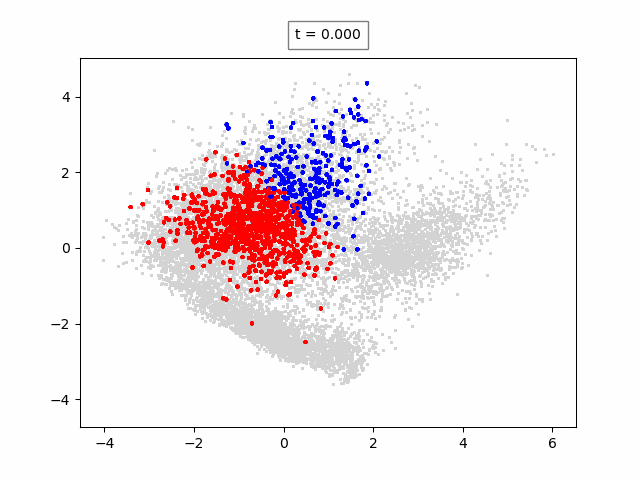

Initial state figure (with background) saved at: /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/72GS_dim8-f_Lip=1e-2-t_size=50-network=64_64_64_initial_state_with_background_x1.png
Animation saved at: /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/72GS_dim8-f_Lip=1e-2-t_size=50-network=64_64_64_classify_x1_hat_trajectory.gif


<Figure size 640x480 with 0 Axes>

In [8]:


source_t, target_t = 0, 4
optimal_k = 2
start_i = 0
index = 10
intermediate_t = []
d_red = 2
exp_memo = folder_name
output_file_classify_X1_hat =  f"{result_dir}{folder_name}_classify_x1_hat_trajectory.gif"
output_file_classify_X1_hat_2 = f"{result_dir}{folder_name}_initial_state_with_background_x1.png"

classify_X1_hat(full_matrix,pca,source_t,target_t,X1_trpts,mats,optimal_k,start_i,index,p,reverse = False, intermediate_t = intermediate_t, d_red=d_red, random_state=42, exp_memo=exp_memo, output_file =output_file_classify_X1_hat, output_file_2 = output_file_classify_X1_hat_2)




## Perform cluster analysis on ancestral cell states and classify trajectories into distinct origins

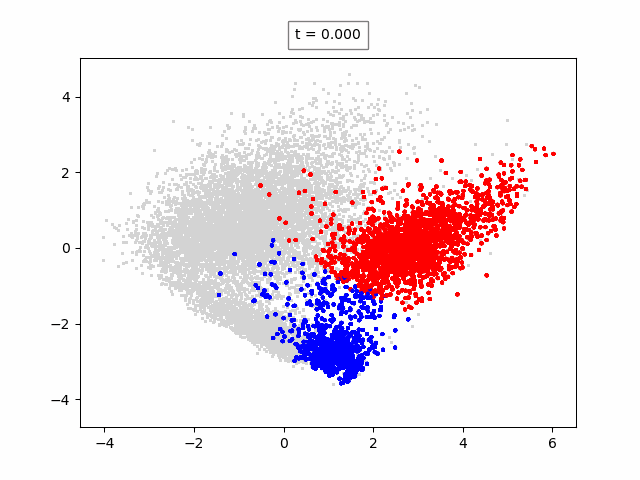

Initial state figure (with background) saved at: /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/72GS_dim8-f_Lip=1e-2-t_size=50-network=64_64_64_initial_state_with_background_x2.png
Animation saved at: /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/72GS_dim8-f_Lip=1e-2-t_size=50-network=64_64_64_classify_x2_hat_trajectory.gif


<Figure size 640x480 with 0 Axes>

In [9]:
source_t, target_t = 0, 4
optimal_k = 2
start_i = 0
index = 10
intermediate_t = []
d_red = 2
exp_memo = folder_name
output_file_classify_X2_hat =  f"{result_dir}{folder_name}_classify_x2_hat_trajectory.gif"
output_file_classify_X2_hat_2 = f"{result_dir}{folder_name}_initial_state_with_background_x2.png"

classify_X2_hat(full_matrix,pca,source_t,target_t,X1_trpts,mats,optimal_k,start_i,index,p,reverse = False, intermediate_t = intermediate_t, d_red=d_red, random_state=42, exp_memo=exp_memo, output_file =output_file_classify_X2_hat, output_file_2 = output_file_classify_X2_hat_2)




## Visualize static plots of the classified trajectories toward distinct fates and save the corresponding fate labels.

In [10]:
source_t, target_t = 0, 4
optimal_k = 2
start_i = 0
index = 1
intermediate_t = []
d_red = 2
exp_memo = folder_name
output_file_cluster_plot_target =  f"{result_dir}{folder_name}_static_cluster_plot_target.png"


X1_hat_labels = generate_static_cluster_plot_target(pca,source_t,target_t,X1_trpts,mats,optimal_k,start_i,index,p,reverse = False, intermediate_t = [], d_red=d_red, random_state=42, exp_memo=exp_memo, output_file =output_file_cluster_plot_target)


# Convert the labels into a DataFrame for saving
df_clusters = pd.DataFrame({
    "Cell_Index": np.arange(len(X1_hat_labels)),  # Assuming each cell has an index
    "Cluster_Label": X1_hat_labels
})

# Define the filename
cluster_save_path = f"{result_dir}{exp_memo}_X1_hat_clusters.csv"

# Save as CSV
df_clusters.to_csv(cluster_save_path, index=False)
print(f"Cluster labels saved to {cluster_save_path}")

# Return the saved filename for future use
cluster_save_path

Static cluster plot saved to /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/72GS_dim8-f_Lip=1e-2-t_size=50-network=64_64_64_static_cluster_plot_target.png
Cluster labels saved to /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/72GS_dim8-f_Lip=1e-2-t_size=50-network=64_64_64_X1_hat_clusters.csv


'/Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/72GS_dim8-f_Lip=1e-2-t_size=50-network=64_64_64_X1_hat_clusters.csv'

## Visualize static plots of the classified trajectories toward distinct ancestral cells and save the corresponding ancestral labels.

In [11]:
source_t, target_t = 0, 4
optimal_k = 2
start_i = 0
index = 1
intermediate_t = []
d_red = 2
exp_memo = folder_name
output_file_cluster_plot_source =  f"{result_dir}{folder_name}_static_cluster_plot_source.png"


X2_hat_labels = generate_static_cluster_plot_source(pca,source_t,target_t,X1_trpts,mats,optimal_k,start_i,index,p,reverse = False, intermediate_t = [], d_red=d_red, random_state=42, exp_memo=exp_memo, output_file =output_file_cluster_plot_source)


# Convert the labels into a DataFrame for saving
df_clusters = pd.DataFrame({
    "Cell_Index": np.arange(len(X2_hat_labels)),  # Assuming each cell has an index
    "Cluster_Label": X2_hat_labels
})

# Define the filename
cluster_save_path = f"{result_dir}{exp_memo}_X2_hat_clusters.csv"

# Save as CSV
df_clusters.to_csv(cluster_save_path, index=False)
print(f"Cluster labels saved to {cluster_save_path}")

# Return the saved filename for future use
cluster_save_path

Static cluster plot saved to /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/72GS_dim8-f_Lip=1e-2-t_size=50-network=64_64_64_static_cluster_plot_source.png
Cluster labels saved to /Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/72GS_dim8-f_Lip=1e-2-t_size=50-network=64_64_64_X2_hat_clusters.csv


'/Users/yuchench/Desktop/source_code_threshold_v1_updated/assets/Transport_genes/72GS_dim8-f_Lip=1e-2-t_size=50-network=64_64_64_X2_hat_clusters.csv'